# Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.nn.utils as nn_utils

import torch.optim as optim
from sklearn.model_selection import train_test_split 
import numpy as np

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

import datetime 

import statistics


# Constants

In [3]:
DEVICE  = torch.device(f"cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE  = "cpu"
print(DEVICE)

CROP_CLASSES = ["No data", "Wheat", "Rye", "Barley", "Oats", "Corn", "Oil Seeds", "Root Crops",
                "Meadows", "Forage Crops"]
CROP_IDS = [-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]



cuda:0


# Dataset loading

## Helper functions

In [4]:
class ImageLabelDataset(Dataset):
    def __init__(self, image_array, label_array):
        self.images = torch.tensor(image_array, dtype=torch.float32)  # (N, 4, 64, 64)
        self.labels = torch.tensor(label_array, dtype=torch.float32)  # (N, 1, 64, 64)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


In [5]:
def remap_labels_for_ce_loss(labels, ignore_index=-1):
    labels = labels.clone().detach()
    mask = (labels != ignore_index)
    labels[mask] -= 1
    return labels


In [6]:
def plot_losses(losses_g, losses_d, save_path=None):
    plt.figure(figsize=(10, 5))
    plt.plot(losses_g, label='Generator Loss')
    plt.plot(losses_d, label='Discriminator Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Generator and Discriminator Loss Over Time")
    if save_path:
        plt.savefig(save_path)
    plt.show()

# Save model function
def save_model(model, path):
    torch.save(model.state_dict(), path)


In [7]:
def plot_class_distribution(class_percentage):
    """
    Plot the class distribution as a bar chart.
    
    Parameters:
    - class_percentage: dictionary with class IDs as keys and their respective percentage of pixels.
    """
    classes = list(class_percentage.keys())
    percentages = list(class_percentage.values())
    
    plt.bar(classes, percentages, color='b', alpha=0.7)
    plt.xlabel('Class ID')
    plt.ylabel('Percentage of Pixels (%)')
    plt.title('Class Distribution Across Dataset')
    plt.xticks(classes)  # Ensure all class IDs are labeled on the x-axis
    plt.show()
    
def calculate_overall_class_distribution(labels_dataset, include_no_data=True, show_plot=True):
    """
    Calculate the overall class distribution across all patches in the dataset.
    
    Parameters:
    - labels_dataset: numpy array of shape (num_patches, 64, 64) representing the patches.
    
    Returns:
    - overall_class_percentage: dictionary with the class ID as key and percentage of pixels across all patches.
    """
    if include_no_data:
        overall_class_counts = {i: 0 for i in (set(range(0, 10)))} # Assuming 10 classes
    else:
        overall_class_counts = {i: 0 for i in range(1, 10)}
    total_pixels = 0

    # Loop through all patches in the dataset
    for labels_patch in labels_dataset:
        flattened_patch = labels_patch.flatten()
        total_pixels += flattened_patch.size
        
        # Count class pixels in the current patch
        class_counts = {i: np.sum(flattened_patch == i) for i in overall_class_counts.keys()}

        for cls, count in class_counts.items():
            overall_class_counts[cls] += count

    # Calculate the percentage for each class across all patches
    overall_class_percentage = {cls: (count / total_pixels) * 100 for cls, count in overall_class_counts.items()}   

    if show_plot:
        plot_class_distribution(overall_class_percentage)
    
    return overall_class_percentage


In [8]:
def find_best_seed_value(data, labels):
    min_std = None
    index = None
    extreme_diffs = None
    extreme_diff_index = None
    for i in range(1,1000):
        _, _, train_labels, _ = train_test_split(data, labels, test_size=0.2, random_state=i)

        dict_percs = calculate_overall_class_distribution(train_labels, include_no_data= False, show_plot=False)
        values = dict_percs.values()

        std = statistics.variance(values)

        if i%100==0:
            print(i)

        if min_std == None:
            min_std = std
            index = i
        elif std<min_std:
            min_std = std
            index = i

        max_min_diff = max(values)- min(values)
        if extreme_diffs == None:
            extreme_diffs = max_min_diff
            extreme_diff_index = i
        elif max_min_diff<extreme_diffs:
            extreme_diffs = max_min_diff
            extreme_diff_index = i

    print(index, min_std) 
    print(extreme_diff_index, extreme_diffs)


## Load and split data

In [9]:
#Load dataset
# agumented_data = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/7_augumented_data_64X64_majority60.npy') 
# agumented_labels = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/8_augumented_labels_64X64_majority60.npy') 

# original_data = np.load(r"../Dataset/s2-utm-33N-18E-242N-2018/9_filtered_data_64X64_majority60.npy")
# original_labels = np.load(r"../Dataset/s2-utm-33N-18E-242N-2018/10_filtered_labels_64X64_majority60.npy")

# data = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/DS2/11_final_gan_data_without_mixed_patches_64X64_majority60.npy')
# labels = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/DS2/12_final_gan_labels_without_mixed_patches_64X64_majority60.npy')

data = np.load('../Dataset/s2-utm-33N-18E-242N-2018/DS3/11_final_gan_data_without_mixed_patches_64X64_majority60.npy')
labels = np.load('../Dataset/s2-utm-33N-18E-242N-2018/DS3/12_final_gan_labels_without_mixed_patches_64X64_majority60.npy')

# Update labels to bring the labels in to ranging from 0 to 9
# labels_upadated = remap_labels_for_ce_loss(torch.tensor(labels))

#Update training labels to fit to training transformers
labels_upadated = np.where(labels == -1, 0, labels)

print(data.shape)
print(labels.shape)


(4403, 64, 64, 4)
(4403, 64, 64)


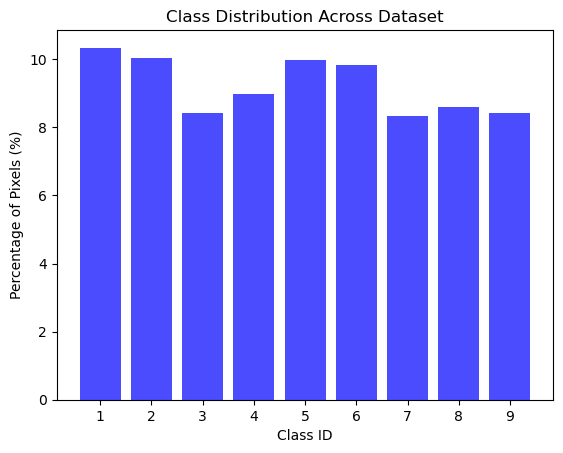

{1: 10.33975058560477,
 2: 10.04244941395159,
 3: 8.414706609792022,
 4: 8.969166467028678,
 5: 9.973463397483675,
 6: 9.82980722733887,
 7: 8.32405155318356,
 8: 8.584807881707835,
 9: 8.436874744907014}

In [10]:
seed_value = 636
train_data, validation_test_data, train_labels, validation_test_labels = train_test_split(data, labels_upadated, test_size=0.2, random_state=seed_value)
validation_data, test_data, validation_labels, test_labels = train_test_split(validation_test_data, validation_test_labels, test_size=0.5, random_state=seed_value)

calculate_overall_class_distribution(train_labels, include_no_data= False)


# GAN

## Generator

class PatchEmbeddingGenerator(nn.Module):
    def __init__(self, noise_dim, label_dim, emb_dim, patch_size=8, num_patches=64):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = num_patches  # 8x8 patches for 64x64 images
        
        # Project (noise + label embedding) to patch embeddings sequence
        self.fc = nn.Linear(noise_dim + label_dim, emb_dim * num_patches)
        
    def forward(self, z, labels):
        # z: [B, noise_dim], labels: [B, label_dim]
        x = torch.cat([z, labels], dim=1)
        x = self.fc(x)  # [B, emb_dim * num_patches]
        x = x.view(-1, self.num_patches, x.size(-1) // self.num_patches)  # [B, num_patches, emb_dim]
        return x

class TransformerBlock(nn.Module):
    def __init__(self, emb_dim, num_heads, ff_mult=4):
        super().__init__()
        self.block = nn.TransformerEncoderLayer(
            d_model=emb_dim, 
            nhead=num_heads, 
            dim_feedforward=ff_mult * emb_dim,
            batch_first=True
        )

    def forward(self, x):
        return self.block(x)

class TransformerEncoder(nn.Module):
    def __init__(self, emb_dim, depth, num_heads):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerBlock(emb_dim, num_heads) for _ in range(depth)
        ])

    def forward(self, x):
        skips = []
        for layer in self.layers:
            x = layer(x)
            skips.append(x)
        return x, skips

class TransformerDecoder(nn.Module):
    def __init__(self, emb_dim, depth, num_heads):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerBlock(emb_dim, num_heads) for _ in range(depth)
        ])

    def forward(self, x, skips):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(skips):
                x = x + skips[-(i + 1)]  # U-Net-style skip connection
        return x

class UNetTransformerGenerator(nn.Module):
    def __init__(self, noise_dim=100, label_dim=4096, emb_dim=512, 
                 patch_size=8, img_size=64, num_heads=8, depth=4, out_channels=4):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.emb_dim = emb_dim
        self.out_channels = out_channels

        # Input projection
        self.patch_embed = PatchEmbeddingGenerator(noise_dim, label_dim, emb_dim, patch_size, self.num_patches)

        # Positional embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, emb_dim))

        # Transformer encoder/decoder
        self.encoder = TransformerEncoder(emb_dim, depth=depth, num_heads=num_heads)
        self.bottleneck = TransformerBlock(emb_dim, num_heads)
        self.decoder = TransformerDecoder(emb_dim, depth=depth, num_heads=num_heads)

        # Output projection
        self.pixel_proj = nn.Linear(emb_dim, patch_size * patch_size * out_channels)

    def forward(self, z, labels):
        B = z.size(0)
        
        x = self.patch_embed(z, labels)
        
        x = x + self.pos_embed

        x_enc, skips = self.encoder(x)
        x = self.bottleneck(x_enc)
        x = self.decoder(x, skips)

        patches = self.pixel_proj(x)  # [B, num_patches, patch_area * C]
        patches = patches.view(B, self.num_patches, self.out_channels, self.patch_size, self.patch_size)

        return self.combine_patches(patches, grid_size=int(self.num_patches ** 0.5))

    def combine_patches(self, patches, grid_size):
        B, N, C, H, W = patches.size()
        patches = patches.permute(0, 2, 1, 3, 4)  # [B, C, N, H, W]
        patches = patches.contiguous().view(B, C, grid_size, grid_size, H, W)
        patches = patches.permute(0, 1, 2, 4, 3, 5).contiguous()
        images = patches.view(B, C, grid_size * H, grid_size * W)
        return torch.tanh(images)


In [11]:
class SpatialLabelEmbedding(nn.Module):
    def __init__(self, num_classes=10, emb_dim=512):
        super().__init__()
        self.embedding = nn.Embedding(num_classes, emb_dim)

    def forward(self, label_map):
        # label_map: [B, 64, 64]
        x = self.embedding(label_map)  # [B, 64, 64, emb_dim]
        x = x.permute(0, 3, 1, 2)      # [B, emb_dim, 64, 64]
        return x


class PatchEmbeddingGenerator(nn.Module):
    def __init__(self, noise_dim, emb_dim, patch_size=16, image_size=64):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2

        self.noise_proj = nn.Linear(noise_dim, emb_dim * self.num_patches)
        self.label_conv = nn.Conv2d(emb_dim, emb_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, z, embedded_labels):
        B = z.size(0)
        noise = self.noise_proj(z).view(B, self.num_patches, -1)  # [B, N, emb_dim]

        label_patches = self.label_conv(embedded_labels)  # [B, emb_dim, 8, 8]
        label_patches = label_patches.flatten(2).transpose(1, 2)  # [B, N, emb_dim]

        return noise + label_patches  # conditioning + latent
    
class TransformerEncoderBlock(nn.Module):
    def __init__(self, emb_dim, num_heads, ff_mult=4):
        super().__init__()
        self.block = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            dropout=0.3,
            activation='gelu',
            nhead=num_heads, 
            dim_feedforward=ff_mult * emb_dim,
            batch_first=True
        )

    def forward(self, x):
        return self.block(x)

class TransformerEncoder(nn.Module):
    def __init__(self, emb_dim, depth, num_heads):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(emb_dim, num_heads) for _ in range(depth)
        ])

    def forward(self, x):
        skips = []
        for layer in self.layers:
            x = layer(x)
            skips.append(x)
        return x, skips
    
class TransformerDecoderBlock(nn.Module):
    def __init__(self, emb_dim, num_heads, ff_mult=4):
        super().__init__()
        self.block = nn.TransformerDecoderLayer(
            d_model=emb_dim, 
            dropout=0.3,            
            activation='gelu',
            nhead=num_heads, 
            dim_feedforward=ff_mult * emb_dim,
            batch_first=True
        )

    def forward(self, x, memory):
        return self.block(tgt=x, memory=memory)  # ✅ Pass memory

class TransformerDecoder(nn.Module):
    def __init__(self, emb_dim, depth, num_heads):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerDecoderBlock(emb_dim, num_heads) for _ in range(depth)
        ])

    def forward(self, x, skips):
        for i, layer in enumerate(self.layers):
            skip = skips[-(i + 1)] if i < len(skips) else None
            x = layer(x, memory=skip) if skip is not None else layer(x, memory=x)
        return x


class UNetTransformerGenerator(nn.Module):
    def __init__(self, noise_dim=100, num_classes=10, emb_dim=256, 
                 patch_size=16, img_size=64, num_heads=8, depth=4, out_channels=4):
        super().__init__()
        self.label_embedder = SpatialLabelEmbedding(num_classes=num_classes, emb_dim=emb_dim)
        self.patch_embed = PatchEmbeddingGenerator(noise_dim, emb_dim, patch_size, img_size)

        self.pos_embed = nn.Parameter(torch.zeros(1, (img_size // patch_size) ** 2, emb_dim))

        self.encoder = TransformerEncoder(emb_dim, depth, num_heads)
        self.bottleneck = TransformerEncoderBlock(emb_dim, num_heads)
        self.decoder = TransformerDecoder(emb_dim, depth, num_heads)

        self.pixel_proj = nn.Linear(emb_dim, patch_size * patch_size * out_channels)
        self.patch_size = patch_size
        self.out_channels = out_channels
        self.num_patches = (img_size // patch_size) ** 2

    def forward(self, z, label_map):
        embedded_labels = self.label_embedder(label_map)  # [B, emb_dim, 64, 64]
        x = self.patch_embed(z, embedded_labels) + self.pos_embed  # [B, N, emb_dim]

        x_enc, skips = self.encoder(x)
        x = self.bottleneck(x_enc)
        x = self.decoder(x, skips)

        B = x.size(0)
        patches = self.pixel_proj(x).view(B, self.num_patches, self.out_channels, self.patch_size, self.patch_size)
        return self.combine_patches(patches, grid_size=int(self.num_patches**0.5))

    def combine_patches(self, patches, grid_size):
        B, N, C, H, W = patches.size()
        patches = patches.permute(0, 2, 1, 3, 4).contiguous()
        patches = patches.view(B, C, grid_size, grid_size, H, W)
        patches = patches.permute(0, 1, 2, 4, 3, 5).contiguous()
        return torch.tanh(patches.view(B, C, grid_size * H, grid_size * W))


## Discriminator

In [12]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=4, patch_size=16, emb_dim=256):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: [B, C=4, 64, 64]
        x = self.proj(x)  # [B, emb_dim, 4, 4]
        x = x.flatten(2)   # [B, emb_dim, 16]
        x = x.transpose(1, 2)  # [B, 16, emb_dim]
        return x

class TransformerDiscriminator(nn.Module):
    def __init__(self, emb_dim=256, num_heads=8, num_layers=8, num_classes=10, patch_size=16):
        super().__init__()
        self.patch_size = patch_size
        self.patch_embed = PatchEmbedding(in_channels=4, patch_size=patch_size, emb_dim=emb_dim)
        self.patch_embed.proj = nn_utils.spectral_norm(self.patch_embed.proj)
        
        self.num_patches = (64 // patch_size) ** 2  # 16 patches for 16x16 patch size
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, emb_dim))
        self.num_classes = num_classes

        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, 
                                                   nhead=num_heads, 
                                                   dim_feedforward=emb_dim*4,
                                                   dropout=0.2,
                                                   activation='relu')
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, emb_dim))
        self.norm = nn.LayerNorm(emb_dim)

        # Adversarial output head
        self.adv_head = nn_utils.spectral_norm(nn.Linear(emb_dim, 1))

        # Segmentation head (MLP per patch)
        self.seg_head = nn_utils.spectral_norm(nn.Linear(emb_dim, self.num_classes))

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)  # [B, 16, emb_dim]
        cls_tokens = self.cls_token.expand(B, -1, -1)  # [B, 1, emb_dim]
        x = torch.cat((cls_tokens, x), dim=1)  # [B, 17, emb_dim]
        x = x + self.pos_embed[:, :x.size(1), :]
        x = self.transformer(x)  # [B, 17, emb_dim]
        x = self.norm(x)

        # Adversarial score from CLS token
        real_fake = self.adv_head(x[:, 0])  # [B, 1]

        # Segmentation logits for patches (skip CLS token)
        seg_logits = self.seg_head(x[:, 1:])  # [B, 16, num_classes=9]

        # Reshape seg_logits to spatial map 4x4
        seg_map = seg_logits.permute(0, 2, 1).contiguous().view(B, self.num_classes, 4, 4)

        # Upsample seg_map to 64x64 for pixelwise supervision
        seg_map = nn.functional.interpolate(seg_map, size=(64, 64), mode='bilinear', align_corners=False)

        return real_fake.view(-1), seg_map


## Helper functions

In [13]:
def load_models(generator, discriminator, g_optimizer, d_optimizer, path):
    checkpoint = torch.load(path, map_location=DEVICE)
    
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    g_optimizer.load_state_dict(checkpoint['g_optimizer_state_dict'])
    d_optimizer.load_state_dict(checkpoint['d_optimizer_state_dict'])
    
    epoch = checkpoint.get('epoch', 0)
    print(f"Models loaded from {path} (Epoch {epoch})")
    return epoch

def save_models(generator, discriminator, g_optimizer, d_optimizer, epoch, path, modelid=0):
    epoch+=1

    filename = r'/acgan_checkpoint-Model '+str(modelid)+r'-Epoch '+str(epoch)+r'_'+ str(datetime.date.today()) +r'.pth'
    full_path = path + filename
    #print(full_path)

    torch.save({
        'epoch': epoch,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'g_optimizer_state_dict': g_optimizer.state_dict(),
        'd_optimizer_state_dict': d_optimizer.state_dict(),
    }, full_path)
    
    print(f"Models saved to {full_path}")


In [14]:
def validate(generator, val_loader, noise_dim = 100):
    generator.eval()
    with torch.no_grad():
        total_loss = 0
        for val_imgs, val_labels in val_loader:
            val_imgs = val_imgs.to(DEVICE)
            val_labels = val_labels.to(DEVICE).long()


            # Noise for generation
            z = torch.randn(val_imgs.size(0), noise_dim, device=DEVICE)
            fake_imgs = generator(z, val_labels)

            # Optionally compute a validation metric (e.g., reconstruction loss, FID, or segmentation loss)
            # For example: Mean Absolute Error (if labels match image structure)
            loss = torch.mean(torch.abs(fake_imgs - val_imgs))  # simple MAE
            total_loss += loss.item()
    generator.train()
    return total_loss / len(val_loader)


In [15]:
def test(generator, test_loader, noise_dim = 100):
    generator.eval()
    all_preds = []
    with torch.no_grad():
        for test_imgs, test_labels in test_loader:
            test_imgs = test_imgs.to(DEVICE)
            test_labels = test_labels.to(DEVICE).long()

            z = torch.randn(test_imgs.size(0), noise_dim, device=DEVICE)
            gen_imgs = generator(z, test_labels)

            # Save or evaluate generated images
            all_preds.append(gen_imgs.cpu())
    
    # Combine predictions if needed
    return torch.cat(all_preds, dim=0)


## Train models

In [16]:
def hinge_d_loss(real_logits, fake_logits):
    loss_real = torch.mean(torch.relu(1.0 - real_logits))
    loss_fake = torch.mean(torch.relu(1.0 + fake_logits))
    return 0.5 * (loss_real + loss_fake)


def hinge_g_loss(fake_logits):
    return -torch.mean(fake_logits)


def train_acgan_transformer_hinge(generator, discriminator, g_optimizer, d_optimizer, dataloader, validation_dataloader, epochs=10, noise_dim = 100, modelid=1):
    losses_g, losses_d = [], []

    auxiliary_loss = nn.CrossEntropyLoss(ignore_index=0)

    for epoch in range(epochs):
        g_loss_total, d_loss_total = 0, 0

        for real_imgs, real_labels in dataloader:
            real_imgs = real_imgs.to(DEVICE)  # Expect normalized [-1,1]
            real_imgs += 0.05 * torch.randn_like(real_imgs)
            real_labels = real_labels.to(DEVICE).long()
            batch_size = real_imgs.size(0)

            # ---------------------
            #  Train Discriminator
            # ---------------------
            d_optimizer.zero_grad()

            real_pred, real_seg = discriminator(real_imgs)
            z = torch.randn(batch_size, noise_dim, device=DEVICE)
            fake_imgs = generator(z, real_labels)
            fake_pred, fake_seg = discriminator(fake_imgs.detach())

            d_adv_loss = hinge_d_loss(real_pred, fake_pred)
            d_aux_loss_real = auxiliary_loss(real_seg, real_labels.long())
            d_aux_loss_fake = auxiliary_loss(fake_seg, real_labels)  # Optional: depends on your setup
            d_aux_loss = (d_aux_loss_real + d_aux_loss_fake) / 2

            d_loss = d_adv_loss + d_aux_loss
            d_loss.backward()
            d_optimizer.step()

            # -----------------
            #  Train Generator
            # -----------------
            g_optimizer.zero_grad()
            gen_pred, gen_seg = discriminator(fake_imgs)
            g_adv_loss = hinge_g_loss(gen_pred)
            g_aux_loss = auxiliary_loss(gen_seg, real_labels)
            g_loss = g_adv_loss + g_aux_loss
            g_loss.backward()
            g_optimizer.step()

            g_loss_total += g_loss.item()
            d_loss_total += d_loss.item()
        
        avg_g = g_loss_total / len(dataloader)
        avg_d = d_loss_total / len(dataloader)
        losses_g.append(avg_g)
        losses_d.append(avg_d)

        val_loss = validate(generator, validation_dataloader, noise_dim)
        print(f"Epoch {epoch+1} | discriminator Loss: {avg_d:.4f} | generator Loss: {avg_g:.4f} | Validation Loss: {val_loss:.4f}")

        if ((epoch+1)%10) == 0:
            print("")
            save_models(generator, discriminator, g_optimizer, d_optimizer, epoch, modelid=modelid, path=r'../GAN models/Spatial models')
            print("")
        
    return losses_g, losses_d


In [17]:
def gradient_penalty(discriminator, real_data, fake_data, device="cuda"):
    batch_size = real_data.size(0)
    epsilon = torch.rand(batch_size, 1, 1, 1, device=device)
    interpolated = epsilon * real_data + (1 - epsilon) * fake_data
    interpolated.requires_grad_(True)

    d_interpolated, _ = discriminator(interpolated)

    gradients = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.view(batch_size, -1)
    grad_norm = gradients.norm(2, dim=1)
    gp = ((grad_norm - 1) ** 2).mean()
    return gp

def wgan_g_loss(fake_logits):
    return -torch.mean(fake_logits)

def wgan_d_loss(real_logits, fake_logits):
    return torch.mean(fake_logits) - torch.mean(real_logits)

def train_acgan_transformer_wgan(
    generator, discriminator, g_optimizer, d_optimizer,
    dataloader, validation_dataloader, epochs=10,
    noise_dim=100, d_lr=1e-4, g_lr=1e-4, modelid=1,
    lambda_gp=10.0, gen_iter=5):

    losses_g, losses_d = [], []
    auxiliary_loss = nn.CrossEntropyLoss(ignore_index=0)

    for epoch in range(epochs):
        g_loss_total, d_loss_total = 0.0, 0.0

        for real_imgs, real_labels in dataloader:
            real_imgs = real_imgs.to(DEVICE)  # Expect normalized [-1, 1]
            real_imgs += 0.05 * torch.randn_like(real_imgs)  # noise regularization
            real_labels = real_labels.to(DEVICE).long()
            batch_size = real_imgs.size(0)

            # --------------------------------
            #  Train Discriminator (WGAN-GP)
            # --------------------------------
            d_optimizer.zero_grad()

            # Real
            real_pred, real_seg = discriminator(real_imgs)

            # Fake
            z = torch.randn(batch_size, noise_dim, device=DEVICE)
            fake_imgs = generator(z, real_labels)
            fake_pred, fake_seg = discriminator(fake_imgs.detach())

            # Wasserstein adversarial loss
            d_adv_loss = wgan_d_loss(real_pred, fake_pred)

            # Gradient penalty
            grad_penalty = gradient_penalty(discriminator, real_imgs, fake_imgs.detach(), device=DEVICE)

            # Auxiliary classification loss (same as before)
            d_aux_real = auxiliary_loss(real_seg, real_labels)
            d_aux_fake = auxiliary_loss(fake_seg, real_labels)
            d_aux_loss = (d_aux_real + d_aux_fake) / 2

            # Final discriminator loss
            d_loss = d_adv_loss + lambda_gp * grad_penalty + d_aux_loss

            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 10.0)

            d_optimizer.step()

            # --------------------------
            #  Train Generator (WGAN)
            # --------------------------
            for _ in range(gen_iter): 
                g_optimizer.zero_grad()

                z = torch.randn(batch_size, noise_dim, device=DEVICE)
                fake_imgs = generator(z, real_labels)
                fake_pred, fake_seg = discriminator(fake_imgs.detach())

                gen_pred, gen_seg = discriminator(fake_imgs)  # No detach!
                g_adv_loss = wgan_g_loss(gen_pred)
                g_aux_loss = auxiliary_loss(gen_seg, real_labels)

                g_loss = g_adv_loss + g_aux_loss

                g_loss.backward()
                torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=10.0)

                g_optimizer.step()

                # Track losses
                g_loss_total += g_loss.item()
            
            d_loss_total += d_loss.item()

        avg_g = g_loss_total / (len(dataloader)*gen_iter)
        avg_d = d_loss_total / len(dataloader)
        losses_g.append(avg_g)
        losses_d.append(avg_d)

        wasserstein_distance = torch.mean(fake_pred) - torch.mean(real_pred)
        print(f"Wasserstein dist:{wasserstein_distance}")

        val_loss = validate(generator, validation_dataloader, noise_dim)
        print(f"Epoch {epoch+1} | D Loss: {d_loss.item():.4f} | D Loss Avg: {avg_d:.4f} | G Loss: {g_loss.item():.4f} | G Loss AVG: {avg_g:.4f} | Val Loss: {val_loss:.4f}")

        if ((epoch+1) % 10) == 0:
            print("\nSaving model checkpoint...\n")
            save_models(generator, discriminator, g_optimizer, d_optimizer, epoch, modelid=modelid,
                        path=r'../GAN models/Spatial models')

    return losses_g, losses_d


In [18]:
# import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

# Example random dataset
image_data = np.transpose(train_data, (0, 3, 1, 2))  # (N, 4, 64, 64)

# Assume array2 has shape (N, 64, 64)
#label_data = np.expand_dims(train_labels, axis=1) 

#train data
dataset = ImageLabelDataset(image_data, train_labels)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

val_data = np.transpose(validation_data, (0,3,1,2))
#validation data
dataset_val = ImageLabelDataset(val_data, validation_labels)
loader_val = DataLoader(dataset_val, batch_size=32, shuffle=False)


c:\Users\Sai Suhaas\.conda\envs\myenv\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1 | discriminator Loss: 2.3085 | generator Loss: 0.6880 | Validation Loss: 0.6179
Epoch 2 | discriminator Loss: 1.9830 | generator Loss: 0.4817 | Validation Loss: 0.6179
Epoch 3 | discriminator Loss: 1.8076 | generator Loss: 0.1001 | Validation Loss: 0.6166
Epoch 4 | discriminator Loss: 1.7750 | generator Loss: 0.0459 | Validation Loss: 0.6214
Epoch 5 | discriminator Loss: 1.7354 | generator Loss: 0.1399 | Validation Loss: 0.6219
Epoch 6 | discriminator Loss: 1.7161 | generator Loss: 0.1196 | Validation Loss: 0.6239
Epoch 7 | discriminator Loss: 1.7017 | generator Loss: 0.2261 | Validation Loss: 0.6254
Epoch 8 | discriminator Loss: 1.6895 | generator Loss: 0.1346 | Validation Loss: 0.6252
Epoch 9 | discriminator Loss: 1.6716 | generator Loss: 0.0241 | Validation Loss: 0.6247
Epoch 10 | discriminator Loss: 1.6652 | generator Loss: 0.1925 | Validation Loss: 0.6257

Models saved to ../GAN models/Spatial models/acgan_checkpoint-Model 8-Epoch 10_2025-07-25.pth

Epoch 11 | discriminato

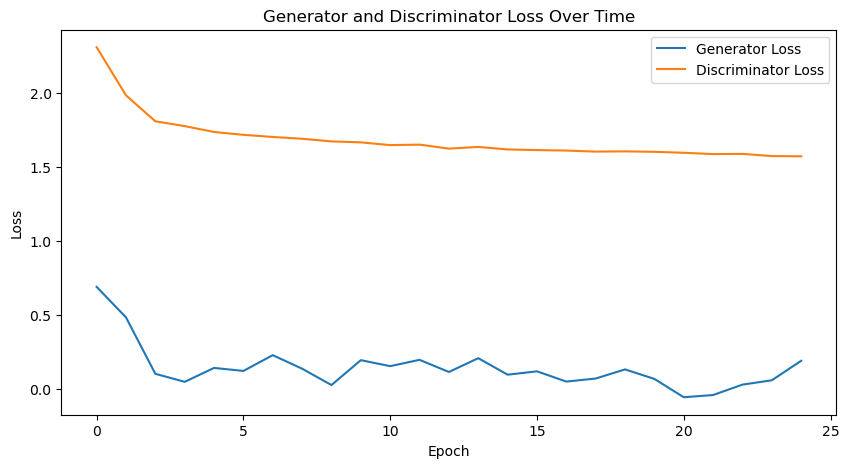

In [19]:
noise_dim = 100

generator = UNetTransformerGenerator(noise_dim=noise_dim, depth=12).to(DEVICE)
discriminator = TransformerDiscriminator().to(DEVICE)

g_optimizer = optim.Adam(generator.parameters(), lr = 1e-4, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr = 1e-5, betas=(0.5, 0.999))

losses_g, losses_d = train_acgan_transformer_hinge(generator, discriminator, g_optimizer, d_optimizer, loader, loader_val, epochs=25, modelid=8)

# torch.backends.cuda.enable_flash_sdp(False)
# torch.backends.cuda.enable_math_sdp(True)
# torch.backends.cuda.enable_mem_efficient_sdp(False)


# losses_g, losses_d = train_acgan_transformer_wgan(generator, discriminator, g_optimizer, d_optimizer, loader, loader_val, epochs=25, modelid=8)
plot_losses(losses_g, losses_d)


## Model testing and Evaluations

In [20]:
class Evaluator:
    def __init__(self, generator, dataloader, num_classes=10, device='cuda'):
        self.G = generator
        self.dataloader = dataloader
        self.device = device
        self.num_classes = num_classes

    def evaluate(self):
        self.G.eval()
        total_iou = 0
        total_pixels = 0
        total_correct = 0
        total_cm = np.zeros((self.num_classes, self.num_classes), dtype=np.int64)
        num_batches = 0

        with torch.no_grad():
            for imgs, labels in self.dataloader:
                imgs = imgs.to(self.device)
                labels = labels.to(self.device).long()

                z = torch.randn(imgs.size(0), 100, device=self.device)
                fake_imgs = self.G(z, labels)

                preds = torch.argmax(fake_imgs, dim=1)

                # Flatten for confusion matrix
                flat_preds = preds.view(-1).cpu().numpy()
                flat_labels = labels.view(-1).cpu().numpy()

                # Mask out ignore index (-1)
                mask = flat_labels != -1
                flat_preds = flat_preds[mask]
                flat_labels = flat_labels[mask]

                # Pixel accuracy
                total_correct += np.sum(flat_preds == flat_labels)
                total_pixels += len(flat_labels)

                # IoU per class
                cm = confusion_matrix(flat_labels, flat_preds, labels=list(range(self.num_classes)))
                total_cm += cm

                iou = self._compute_iou(cm)
                total_iou += np.nanmean(iou)

                num_batches += 1

        pixel_acc = total_correct / total_pixels
        mean_iou = total_iou / num_batches
        confusion = total_cm

        return {
            'pixel_accuracy': pixel_acc,
            'mean_iou': mean_iou,
            'confusion_matrix': confusion
        }

    def _compute_iou(self, cm):
        intersection = np.diag(cm)
        union = np.sum(cm, axis=1) + np.sum(cm, axis=0) - intersection
        iou = intersection / np.maximum(union, 1e-10)
        return iou

    def plot_confusion_matrix(self, cm, class_names=None):
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        plt.title("Confusion Matrix")
        plt.show()

    def visualize_batch(self, real_imgs, labels, preds, n=4):
        for i in range(min(n, real_imgs.size(0))):
            fig, axs = plt.subplots(1, 3, figsize=(12, 4))
            axs[0].imshow(real_imgs[i].permute(1, 2, 0).cpu())
            axs[0].set_title("Input Image")
            axs[1].imshow(labels[i].cpu())
            axs[1].set_title("Ground Truth")
            axs[2].imshow(preds[i].cpu())
            axs[2].set_title("Prediction")
            for ax in axs:
                ax.axis('off')
            plt.tight_layout()
            plt.show()
